# Supplementary: Checking spe-1 patch recordings for a stimulation artifact

**Ashley's comment:** the spe-1 dataset is described as spontaneous activity, but we can't formally rule out that the experimenter delivered stimulation at some points to drive low-firing neurons. Her suggestion for what to look for: *"I think you would see this as a very slight shift in membrane potential unless they had balanced the bridge absolutely perfectly ... you might also see tiny capacitance transients."*

**What this notebook does:** exactly that, and nothing more - for every spe-1 cell, using the **raw, unfiltered** patch recording (not the bandpass-filtered version used elsewhere in the paper, since filtering can hide a slow baseline shift):

1. Plot the resting baseline level across the whole recording, for every cell at a glance - a real shift would show up as a step to a new sustained level.
2. Zoom into a handful of raw-trace snippets for any cell of interest, to look by eye for brief transient blips.

No spike detection, no statistics, no automatic classification - just look at the trace.

In [ ]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ruptures as rpt

sys.path.append('../../datasets/spe-1/spe1_helper_modules/')
import config

RAW_PATCH_DIR = os.path.join(config.SPE1_DATA_ROOT, 'raw_patch_recordings')
CLUSTER_PKL_DIR = config.SPE1_PICKLE_ROOT + '/cluster_pickles/'
ORDINAL_MAP = {'low': 0, 'mid': 1, 'high': 2}

# waveform-SHAPE features only, not spike-timing/ISI features (log_isi, n_spikes_*) or
# the spike time/index itself, which get clustered too but aren't "waveform"
WAVEFORM_FEATURES = ['ramp_amp', 'inflection_time', 'inflection_amp',
                      'peak_amp', 'peak_width', 'peak_sharpness',
                      'exp_lambda', 'exp_const']

In [ ]:
def load_raw_patch(cell_num):
    """Load a cell's raw, unfiltered patch recording (float64, in the units it was recorded in)."""
    fs = config.DICT_PATCH_FS[cell_num]
    trace = np.fromfile(os.path.join(RAW_PATCH_DIR, f'c{cell_num}_patch_ch1.bin'), dtype='float64')
    return trace, fs

def compute_baseline(cell_num, bin_s=1.0):
    """Median voltage per bin_s-second bin, the resting level with spikes averaged out."""
    trace, fs = load_raw_patch(cell_num)
    bin_samples = int(bin_s * fs)
    n_bins = len(trace) // bin_samples
    chunks = trace[:n_bins * bin_samples].reshape(n_bins, bin_samples)
    baseline = np.median(chunks, axis=1)
    t_min = np.arange(n_bins) / 60.0
    return t_min, baseline

def get_pelt_changepoints(signal, t_min):
    """PELT (L2 cost, BIC-style penalty) on a 1D signal already binned to match t_min."""
    valid = ~np.isnan(signal)
    if valid.sum() < 20 or np.nanstd(signal) < 1e-9:
        return []
    algo = rpt.Pelt(model='l2', min_size=5, jump=1).fit(signal.reshape(-1, 1))
    pen = 3 * np.log(len(signal)) * np.nanvar(signal)
    return [round(t_min[b], 2) for b in algo.predict(pen=pen) if b < len(signal)]

def bin_ordinal(spk_min, ordinal, n_bins, duration_min):
    """Per-spike ordinal cluster label (0/1/2) averaged into per-second bins, matching the baseline bins."""
    bin_edges = np.arange(0, duration_min + 1/60, 1/60)[:n_bins + 1]
    bin_idx = np.clip(np.digitize(spk_min, bin_edges) - 1, 0, n_bins - 1)
    sums = np.bincount(bin_idx, weights=ordinal, minlength=n_bins)
    counts = np.bincount(bin_idx, minlength=n_bins)
    with np.errstate(invalid='ignore'):
        binned = sums / counts
    binned[counts == 0] = np.nan
    return pd.Series(binned).interpolate(limit_direction='both').to_numpy()

def load_cluster_df(cell_num):
    """A cell's per-spike waveform-feature dataframe, or None if it was never clustered."""
    path = f'{CLUSTER_PKL_DIR}c{cell_num}_cluster_df.pkl'
    if not os.path.exists(path):
        return None
    with open(path, 'rb') as f:
        return pickle.load(f)

def waveform_cluster_columns(df):
    """Which of this cell's WAVEFORM_FEATURES actually got clustered (some features are unimodal, no _cluster column)."""
    return [f'{feat}_cluster' for feat in WAVEFORM_FEATURES if f'{feat}_cluster' in df.columns]

## 1. Does the baseline level shift anywhere during the recording?

For each cell: split the raw recording into 1-second chunks and take the median voltage in each chunk (the median is barely affected by the handful of tall, brief spikes in each chunk, so this line tracks the *resting* level, not the spikes). A steady, if noisy, flat line means no shift. A step up or down to a new sustained level would be exactly the kind of "slight shift in membrane potential" Ashley described.

In [ ]:
cell_nums = sorted(int(c[1:]) for c in config.CELL_IDS)
baselines = {cell_num: compute_baseline(cell_num) for cell_num in cell_nums}

print(f'Computed baseline traces for {len(baselines)} cells.')

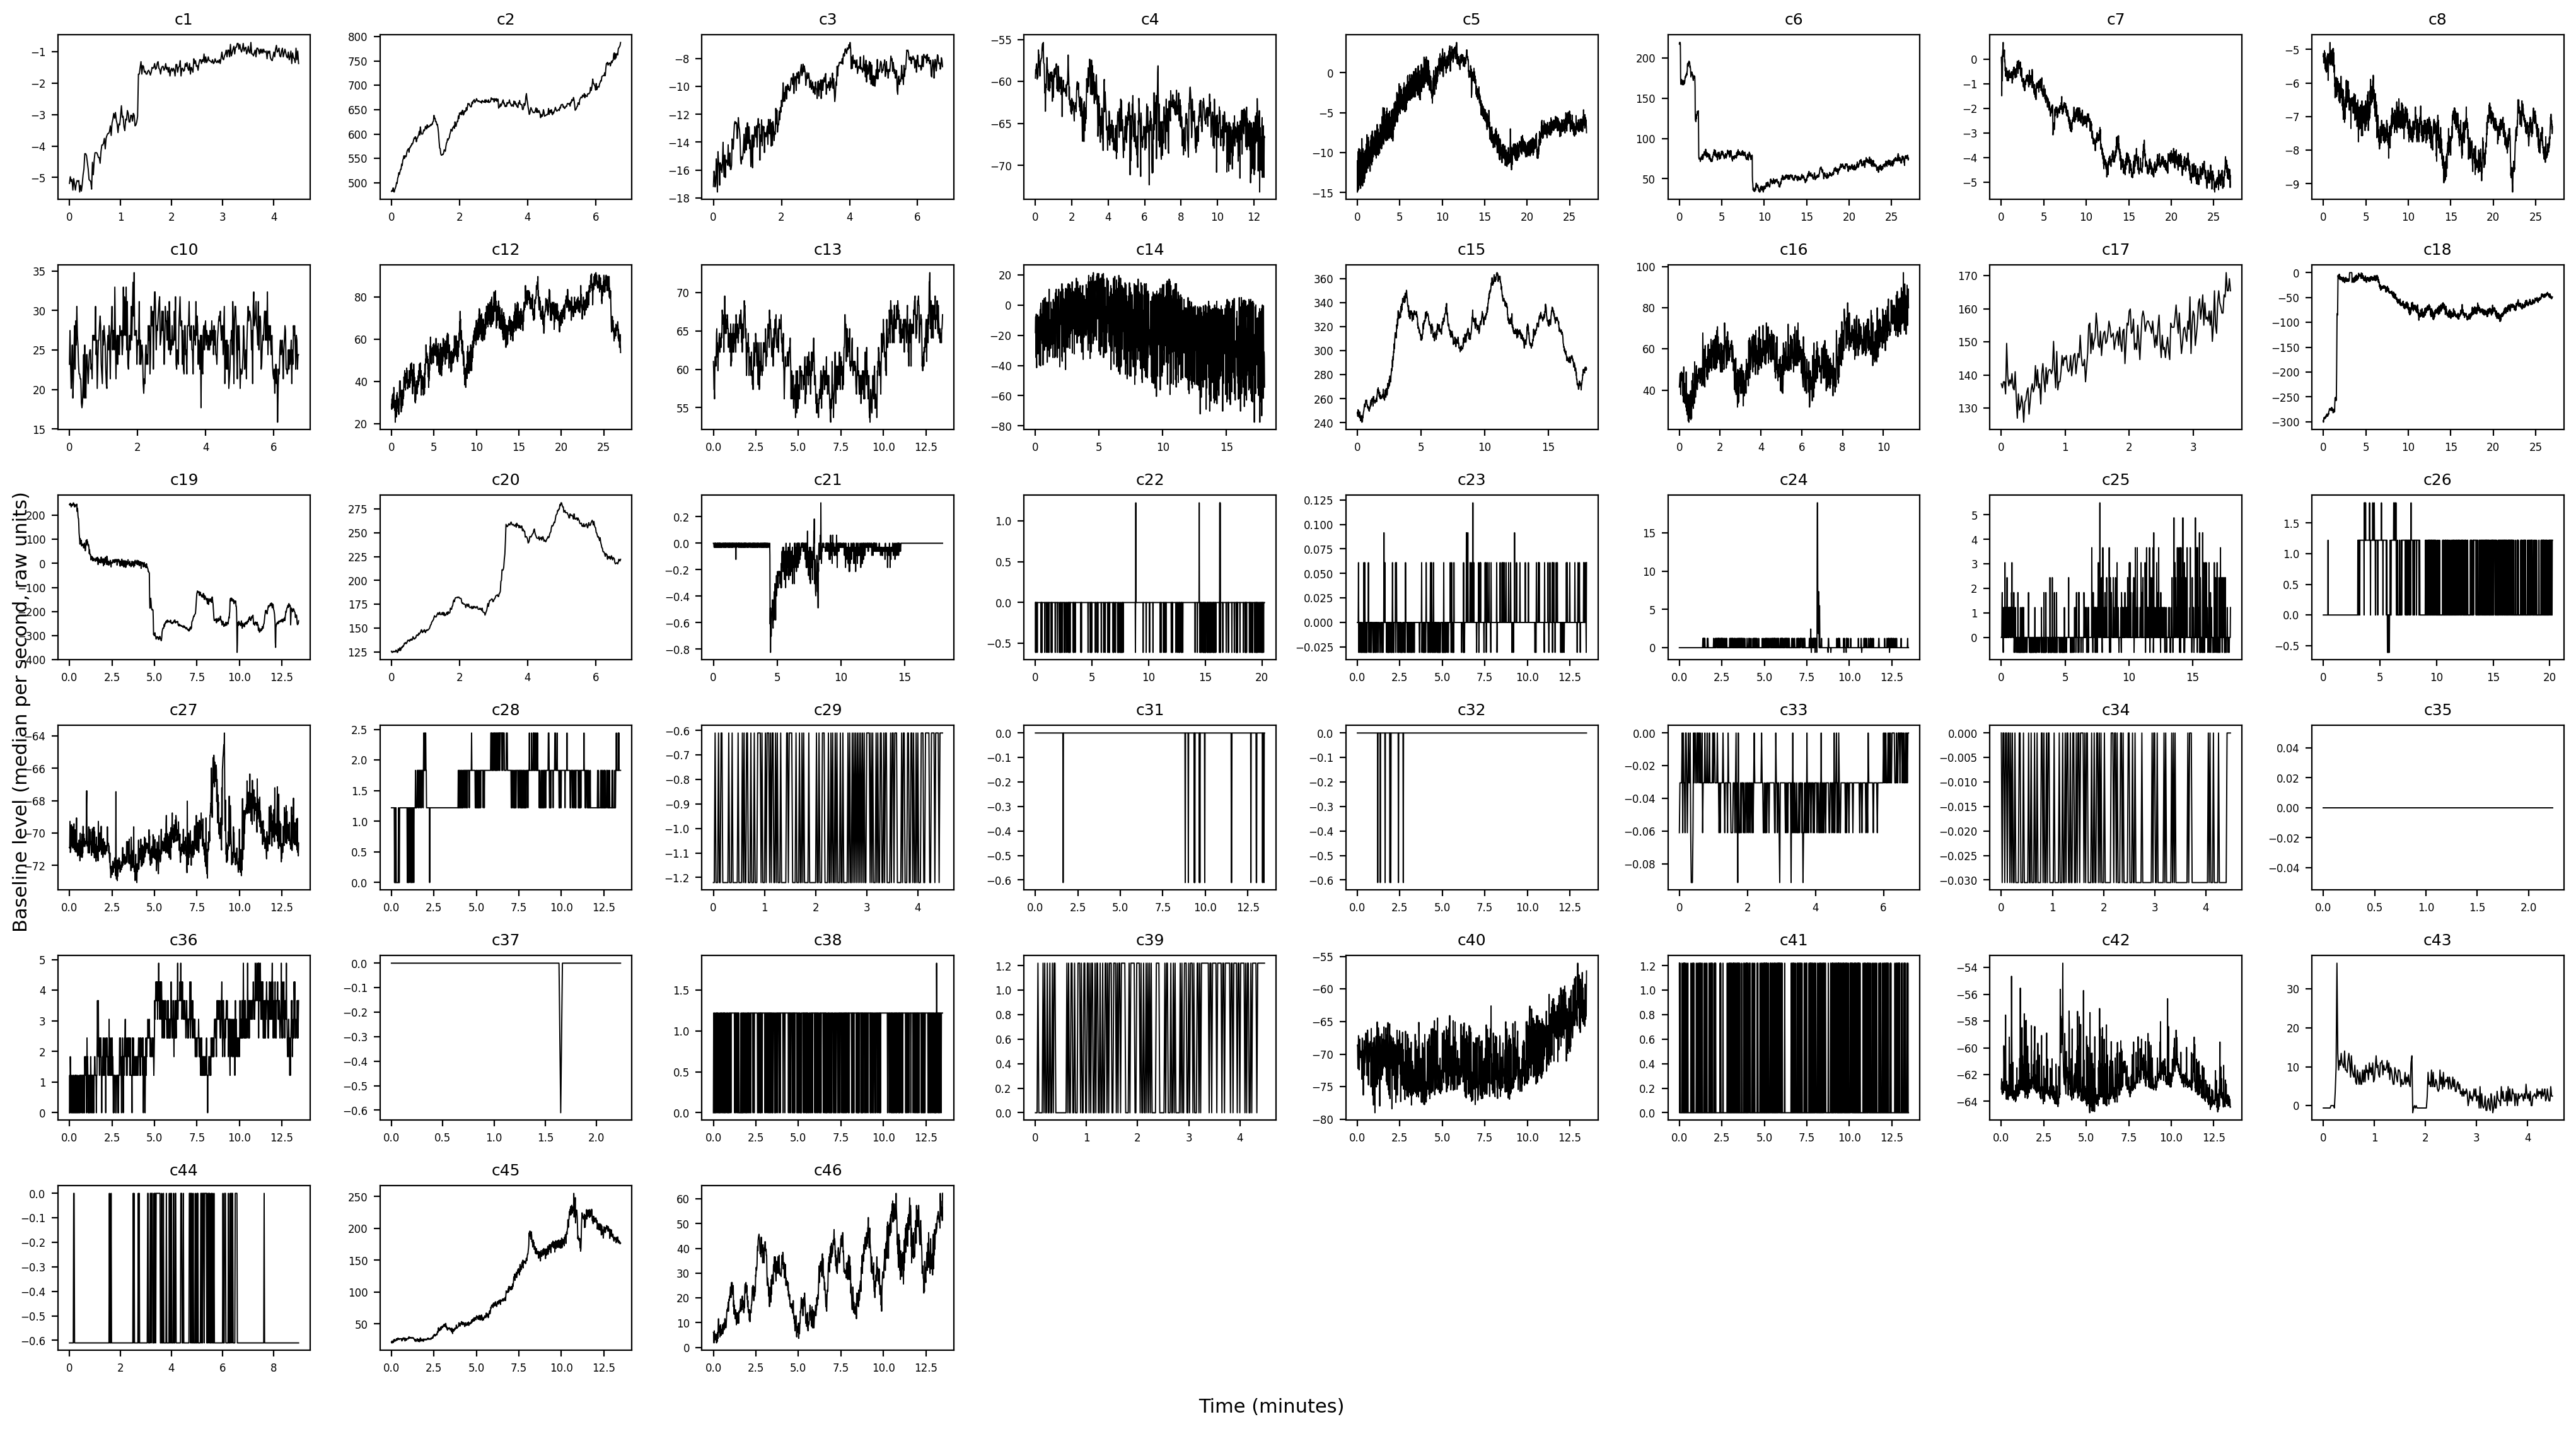

In [3]:
n = len(cell_nums)
ncols = 8
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.6, nrows * 1.9))
axes = axes.flatten()

for ax, cell_num in zip(axes, cell_nums):
    t_min, baseline = baselines[cell_num]
    ax.plot(t_min, baseline, color='black', lw=0.7)
    ax.set_title(f'c{cell_num}', fontsize=9)
    ax.tick_params(labelsize=6)

for ax in axes[n:]:
    ax.axis('off')

fig.supxlabel('Time (minutes)', fontsize=11)
fig.supylabel('Baseline level (median per second, raw units)', fontsize=11)
plt.tight_layout()
plt.show()

### Finding real changes in the baseline, automatically

Instead of eyeballing 43 plots or hand rolling a jump-ratio rule, use PELT (Pruned Exact Linear Time), the standard changepoint-detection method, directly on each cell's per-second baseline. It finds every point where the mean level actually shifts, with a BIC-style penalty so it doesn't just chop the trace into noise-sized pieces.

In [ ]:
baseline_changepoints = {}
for cell_num in cell_nums:
    t_min, baseline = baselines[cell_num]
    typical_step = np.median(np.abs(np.diff(baseline)))
    if typical_step < 1e-9 or len(baseline) < 20:
        continue
    baseline_changepoints[f'c{cell_num}'] = get_pelt_changepoints(baseline, t_min)

print(f'{len(baseline_changepoints)} cells have a usable baseline, PELT changepoints found for '
      f'{sum(len(v) > 0 for v in baseline_changepoints.values())} of them.')

### Do baseline changes line up with waveform-cluster changes?

The pipeline's existing `find_temporal_transitions` table is too sparse for this, it only fits a sigmoid when one clears a quality threshold, so plenty of cells with an obvious cluster change (by eye) aren't in it at all. Do this directly instead: for every cell, take each waveform feature that got clustered into low/mid/high (`peak_amp_cluster`, `peak_width_cluster`, `peak_sharpness_cluster`), turn it into a 0/1/2 signal over time, bin it the same way as the baseline, and run PELT on that too. Same method, same rigor, applied to both signals, so they're directly comparable.

In [ ]:
cluster_changepoints = {}   # cell_id -> {feature: [changepoint minutes]}
for cell_num in cell_nums:
    df = load_cluster_df(cell_num)
    if df is None:
        continue
    feats = waveform_cluster_columns(df)
    spk_min = df['spk_times_ms'].to_numpy() / 60000.0
    t_min, baseline = baselines[cell_num]
    feat_cps = {}
    for feat in feats:
        ordinal = df[feat].map(ORDINAL_MAP).to_numpy().astype(float)
        signal = bin_ordinal(spk_min, ordinal, len(baseline), t_min[-1])
        cps = get_pelt_changepoints(signal, t_min)
        if cps:
            feat_cps[feat] = cps
    if feat_cps:
        cluster_changepoints[f'c{cell_num}'] = feat_cps

print(f'{len(cluster_changepoints)} cells have at least one clustered waveform-shape feature with a real changepoint.')

In [6]:
real_dists = []
dist_meta = []
for cid, feat_cps in cluster_changepoints.items():
    bcps = np.array(baseline_changepoints.get(cid, []))
    if len(bcps) == 0:
        continue
    for feat, cps in feat_cps.items():
        for cp in cps:
            real_dists.append(np.min(np.abs(bcps - cp)))
            dist_meta.append((cid, feat, cp))

real_dists = np.array(real_dists)
print(f'{len(real_dists)} cluster changepoints (across {len(set(m[0] for m in dist_meta))} cells) have a baseline '
      f'changepoint to compare against.')
print(f'Median distance to nearest baseline changepoint: {np.median(real_dists):.2f} min')
print(f'Mean distance: {real_dists.mean():.2f} min')

112 cluster changepoints (across 21 cells) have a baseline changepoint to compare against.
Median distance to nearest baseline changepoint: 1.00 min
Mean distance: 1.89 min


In [7]:
rng = np.random.default_rng(0)
N_SHUFFLE = 2000
durations_min = {f'c{cn}': baselines[cn][0][-1] for cn in cell_nums}

null_medians = np.empty(N_SHUFFLE)
null_means = np.empty(N_SHUFFLE)
for i in range(N_SHUFFLE):
    shuf = np.empty(len(real_dists))
    for j, (cid, feat, cp) in enumerate(dist_meta):
        bcps = np.array(baseline_changepoints[cid])
        t_shuf = rng.uniform(0, durations_min[cid])
        shuf[j] = np.min(np.abs(bcps - t_shuf))
    null_medians[i] = np.median(shuf)
    null_means[i] = shuf.mean()

print(f'Real median: {np.median(real_dists):.2f} min vs. chance {null_medians.mean():.2f} min '
      f'(p = {(null_medians <= np.median(real_dists)).mean():.4f})')
print(f'Real mean: {real_dists.mean():.2f} min vs. chance {null_means.mean():.2f} min '
      f'(p = {(null_means <= real_dists.mean()).mean():.4f})')

Real median: 1.00 min vs. chance 1.29 min (p = 0.0290)
Real mean: 1.89 min vs. chance 1.88 min (p = 0.5380)


### Example: c21

Here's what that overlap actually looks like for one cell, raw baseline on top, the peak-amplitude cluster as a raster in the middle, each cluster's spike rate on the bottom. Worth checking one more thing here too: when a new cluster (e.g. "high") shows up right at the baseline shift, does the cell switch cleanly into that new state, or do the old clusters keep showing up alongside it?

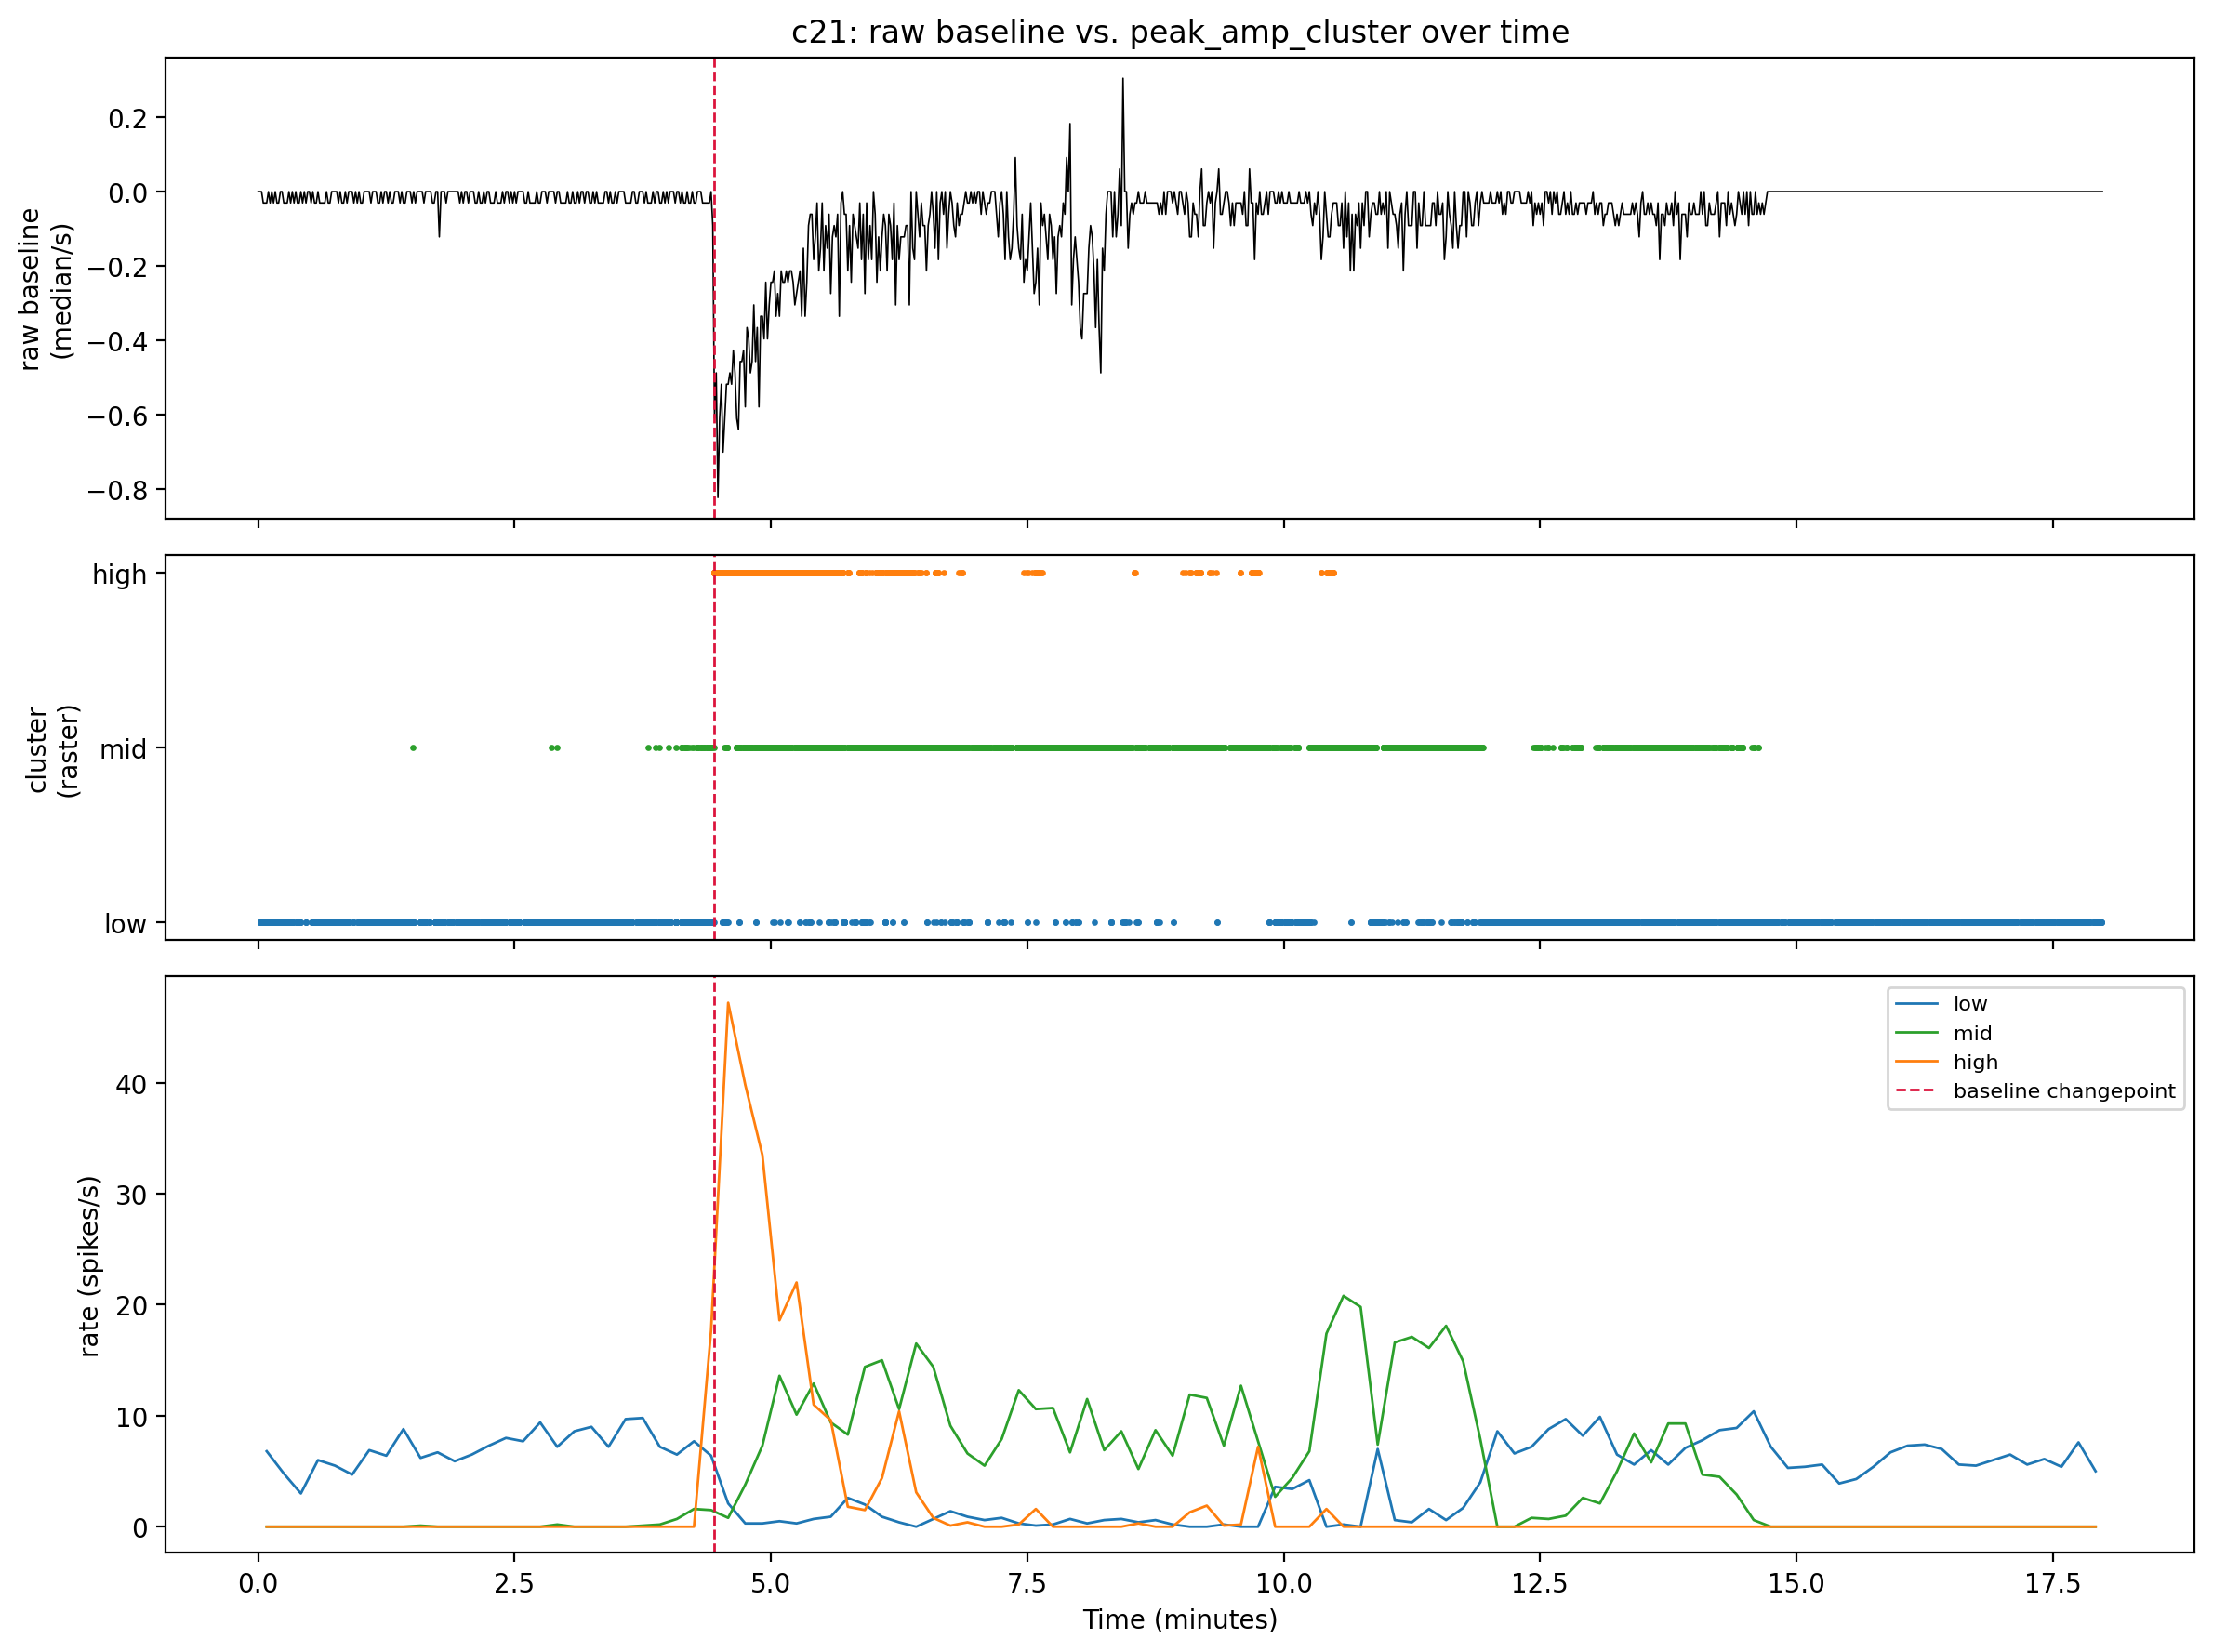

Cluster mix before the changepoint (4.45 min):
low     0.972
mid     0.023
high    0.005
dtype: float64

Cluster mix after:
mid     0.502
low     0.276
high    0.222
dtype: float64


In [8]:
EXAMPLE_CELL = 21
EXAMPLE_FEATURE = 'peak_amp_cluster'

t_min, baseline = baselines[EXAMPLE_CELL]
with open(f'{CLUSTER_PKL_DIR}c{EXAMPLE_CELL}_cluster_df.pkl', 'rb') as f:
    df = pickle.load(f)
spk_min = df['spk_times_ms'].to_numpy() / 60000.0
clusters = df[EXAMPLE_FEATURE].to_numpy()

cp = baseline_changepoints[f'c{EXAMPLE_CELL}'][0]

BIN_S = 10
spk_s = spk_min * 60
bins = np.arange(0, spk_s.max() + BIN_S, BIN_S)
bin_centers_min = (bins[:-1] + BIN_S / 2) / 60
colors = {'low': 'tab:blue', 'mid': 'tab:green', 'high': 'tab:orange'}

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True,
                          gridspec_kw={'height_ratios': [1.2, 1, 1.5]})

axes[0].plot(t_min, baseline, color='black', lw=0.6)
axes[0].set_ylabel('raw baseline\n(median/s)')
axes[0].set_title(f'c{EXAMPLE_CELL}: raw baseline vs. {EXAMPLE_FEATURE} over time')
axes[0].axvline(cp, color='crimson', ls='--', lw=1)

for lab in ['low', 'mid', 'high']:
    mask = clusters == lab
    axes[1].scatter(spk_min[mask], [lab] * mask.sum(), s=2, color=colors[lab])
axes[1].set_ylabel('cluster\n(raster)')
axes[1].axvline(cp, color='crimson', ls='--', lw=1)

for lab in ['low', 'mid', 'high']:
    mask = clusters == lab
    counts, _ = np.histogram(spk_s[mask], bins=bins)
    axes[2].plot(bin_centers_min, counts / BIN_S, color=colors[lab], label=lab, lw=1)
axes[2].axvline(cp, color='crimson', ls='--', lw=1, label='baseline changepoint')
axes[2].set_ylabel('rate (spikes/s)')
axes[2].set_xlabel('Time (minutes)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

before = pd.Series(clusters[spk_min < cp]).value_counts(normalize=True).round(3)
after = pd.Series(clusters[spk_min >= cp]).value_counts(normalize=True).round(3)
print(f'Cluster mix before the changepoint ({cp} min):\n{before}\n')
print(f'Cluster mix after:\n{after}')

### Clean switch, or added variability?

Do this for every cell with an overlapping changepoint, not just c21: split its spikes into before/after that changepoint and see whether one cluster takes over completely, or several keep showing up.

In [9]:
OVERLAP_TOL_MIN = 1.0
mix_rows = []

for cid, feat, cp in dist_meta:
    bcps = np.array(baseline_changepoints[cid])
    if np.min(np.abs(bcps - cp)) > OVERLAP_TOL_MIN:
        continue
    cell_num = int(cid[1:])
    with open(f'{CLUSTER_PKL_DIR}{cid}_cluster_df.pkl', 'rb') as f:
        df = pickle.load(f)
    spk_min = df['spk_times_ms'].to_numpy() / 60000.0
    clusters = df[feat].to_numpy()
    after = clusters[spk_min >= cp]
    if len(after) < 10:
        continue
    props = pd.Series(after).value_counts(normalize=True)
    n_present = (props > 0.10).sum()
    mix_rows.append({
        'cell_id': cid, 'feature': feat, 'changepoint_min': cp,
        'n_clusters_present_after (>10%)': n_present,
        'dominant_cluster_share': round(props.max(), 2),
        'still_mixed': n_present > 1,
    })

mix_df = pd.DataFrame(mix_rows).drop_duplicates(subset=['cell_id', 'feature'])
print(f'{mix_df["still_mixed"].sum()} / {len(mix_df)} overlapping cases still show more than one cluster '
      f'(>10% share) after the changepoint, not a clean switch.')
mix_df

26 / 34 overlapping cases still show more than one cluster (>10% share) after the changepoint, not a clean switch.


,cell_id,feature,changepoint_min,n_clusters_present_after (>10%),dominant_cluster_share,still_mixed
0,c1,peak_amp_cluster,1.33,1,1.00,False
1,c1,peak_sharpness_cluster,1.33,1,0.95,False
2,c1,exp_lambda_cluster,0.83,2,0.88,True
3,c3,peak_amp_cluster,1.92,1,0.99,False
4,c4,peak_amp_cluster,3.90,1,0.97,False
5,c5,inflection_time_cluster,5.23,2,0.53,True
7,c5,inflection_amp_cluster,5.33,2,0.60,True
9,c5,peak_amp_cluster,4.20,2,0.58,True
10,c5,peak_width_cluster,5.47,2,0.56,True
12,c5,peak_sharpness_cluster,4.42,2,0.51,True


## 2. Zoom in on the raw trace for one cell

Set `CELL_TO_INSPECT` below and re-run - shows a few short raw-trace snippets spread across the recording (start / one-third / two-thirds / near the end), so you can look by eye for brief transient blips (Ashley's "tiny capacitance transients") anywhere in the trace, not just in the baseline summary above.

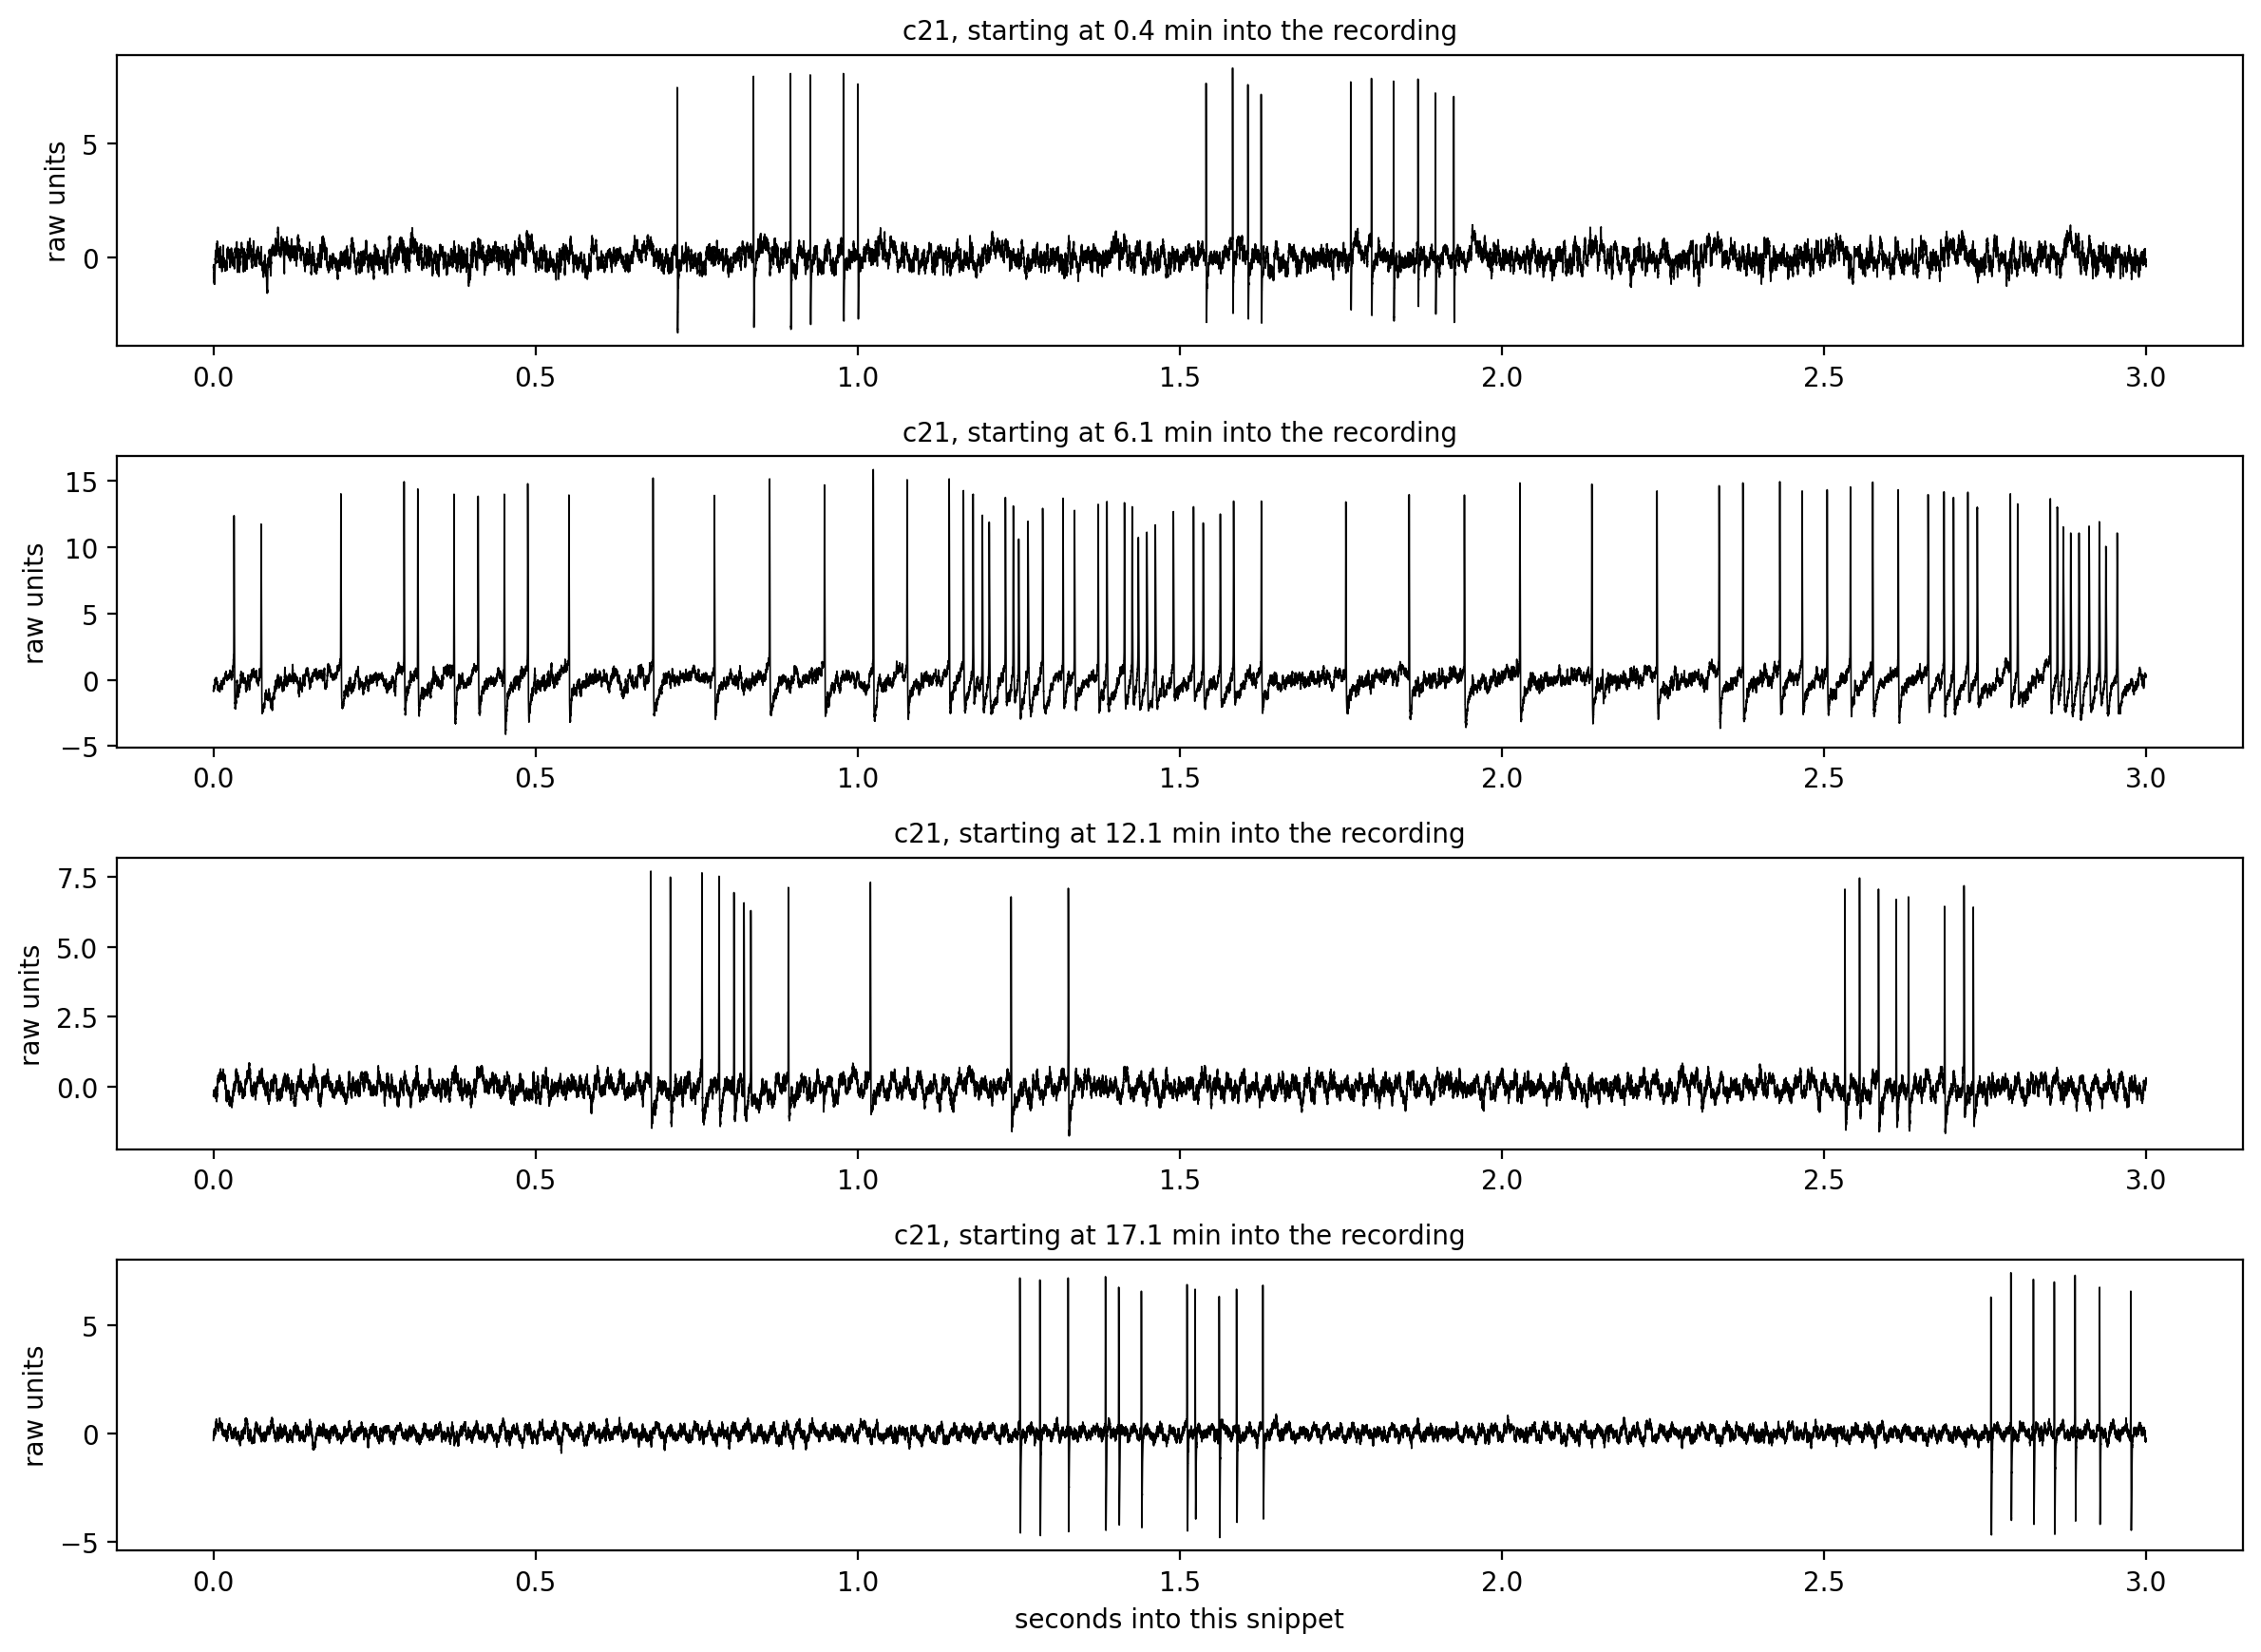

In [10]:
CELL_TO_INSPECT = 21   # change this to any cell number and re-run
SNIPPET_SECONDS = 3

trace, fs = load_raw_patch(CELL_TO_INSPECT)
duration_s = len(trace) / fs
snippet_starts = [duration_s * frac for frac in (0.02, 0.34, 0.67, 0.95)]

fig, axes = plt.subplots(len(snippet_starts), 1, figsize=(12, 2.2 * len(snippet_starts)), sharey=False)
for ax, t0 in zip(axes, snippet_starts):
    i0 = int(t0 * fs)
    i1 = i0 + int(SNIPPET_SECONDS * fs)
    seg = trace[i0:i1]
    t = np.arange(len(seg)) / fs
    ax.plot(t, seg, color='black', lw=0.6)
    ax.set_title(f'c{CELL_TO_INSPECT}, starting at {t0/60:.1f} min into the recording', fontsize=10)
    ax.set_ylabel('raw units')
axes[-1].set_xlabel('seconds into this snippet')
plt.tight_layout()
plt.show()

---
**Data used:** raw, unfiltered `c{N}_patch_ch1.bin` recordings for all 43 spe-1 cells, obtained from the lab's original recording archive and placed in `raw_patch_recordings/` alongside the existing `filt_patch_recordings/` used elsewhere in the pipeline. These are the true pre-processing recordings - no bandpass filter has been applied, so a real sustained shift in resting level would appear directly, rather than as the brief filtered echo a shift becomes after the 10 Hz highpass used everywhere else in the paper.